# ASR robustness visualization

This notebook visualizes how the ASR system behaves under different noise conditions
using the CSVs produced by the experiment scripts.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

transcription_path = "../results/transcription_results.csv"
df = pd.read_csv(transcription_path)
df.head()

,script_id,audio_type,audio_file,reference,hypothesis,wer,keyword_accuracy
0,script_10,clean,script_10_clean.mp3,How many reps are currently using the platform...,How many reps are currently using the platform...,0.1071,0.5
1,script_11,clean,script_11_clean.mp3,Thanks for making time. Have you had a chance ...,Thanks for making time. Have you had a chance ...,0.0189,1.0
2,script_12,clean,script_12_clean.mp3,"Rather than committing to the full rollout, wo...","Rather than committing to the full rollout, wo...",0.0000,1.0
3,script_13,clean,script_13_clean.mp3,How is the platform working for your team in F...,How is the platform working for your team in F...,0.0943,0.6
4,script_14,clean,script_14_clean.mp3,You mentioned you have offices in three cities...,You mentioned you have offices in three cities...,0.0500,1.0


In [4]:
grouped = (
    df.groupby("audio_type")[["wer", "keyword_accuracy"]]
    .mean()
    .sort_index()
)

grouped

,wer,keyword_accuracy
audio_type,,
clean,0.033185,0.8950
heavy_noise,0.060140,0.8425
slight_noise,0.033155,0.8850


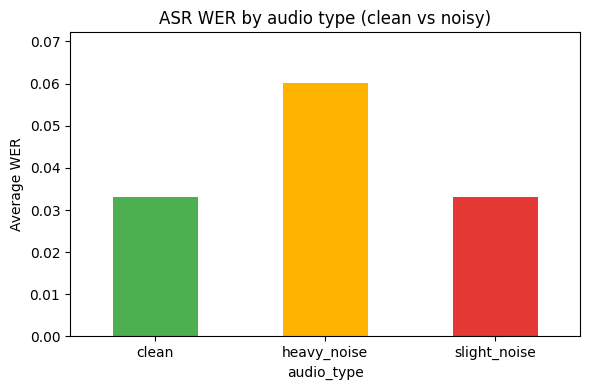

In [5]:
plt.figure(figsize=(6, 4))
grouped["wer"].plot(kind="bar", color=["#4caf50", "#ffb300", "#e53935"])
plt.ylabel("Average WER")
plt.title("ASR WER by audio type (clean vs noisy)")
plt.xticks(rotation=0)
plt.ylim(0, grouped["wer"].max() * 1.2)
plt.tight_layout()
plt.show()

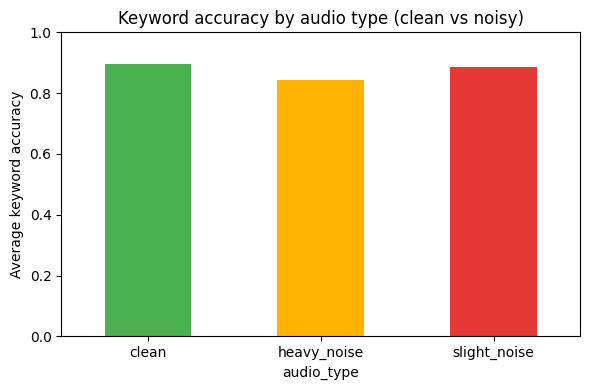

In [6]:
plt.figure(figsize=(6, 4))
grouped["keyword_accuracy"].plot(kind="bar", color=["#4caf50", "#ffb300", "#e53935"])
plt.ylabel("Average keyword accuracy")
plt.title("Keyword accuracy by audio type (clean vs noisy)")
plt.xticks(rotation=0)
plt.ylim(0, min(1.0, grouped["keyword_accuracy"].max() * 1.2))
plt.tight_layout()
plt.show()